# First executed hypothesis tests for *Invisible Ledger*

## tl;dr

The expanded candidate inventory contains 17 matched annual levels and 12 consecutive within-series transitions. Two transitions move in opposite directions, but only Tokopedia FY2022-FY2023 currently belongs to the direct Indonesia-aligned evidence tier. BPS aggregate evidence indicates that growth in estimated e-commerce businesses accounts arithmetically for much of 2022-2024 transaction-value growth. Province evidence does not establish a stable marketplace-use/financial-recordkeeping relationship.

## Context & Methods

This notebook accompanies `scripts/analysis/build_hypothesis_tests.py`. It compares growth only within the same platform series and keeps direct Indonesia-aligned segments, scope-pending issuer pairs, and conditional country reconstructions separate. BPS national decompositions are nominal arithmetic; province correlations are ecological and descriptive.

### Key Assumptions

- Tokopedia FY2021 remains excluded because its transaction and revenue periods are not demonstrably matched.
- Blibli selects the latest available comparative publication vintage for each economic year.
- Bukalapak FY2024 remains excluded because TPV covers nine months and revenue twelve months.
- No candidate tier is treated as advisor-approved.

## Data

Rebuild the derived outputs from repository inputs, then load the bounded result tables.

In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
from IPython.display import Image, display
root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
subprocess.run([sys.executable, str(root / 'scripts/analysis/build_hypothesis_tests.py')], cwd=root, check=True)
output = root / 'outputs/hypothesis_tests_2026-09-10'
levels = pd.read_csv(output / 'indonesia_longitudinal_candidate_levels.csv')
transitions = pd.read_csv(output / 'indonesia_longitudinal_candidate_transitions.csv')
transition_summary = pd.read_csv(output / 'indonesia_longitudinal_transition_summary.csv')
bps_growth = pd.read_csv(output / 'bps_national_growth_anatomy.csv')
province_results = pd.read_csv(output / 'bps_province_hypothesis_results.csv')
hypothesis_status = pd.read_csv(output / 'hypothesis_status.csv')
print(f'{len(levels)} annual levels; {len(transitions)} consecutive transitions')

candidate_levels=17
candidate_transitions=12
province_year_tests=3
report=reports/HYPOTHESIS_TESTS_2026-09-10.md


17 annual levels; 12 consecutive transitions


## Results

The tables and figures below preserve evidence tiers and expose the negative province result rather than treating every hypothesis as confirmed.

,evidence_tier,transitions,series,revenue_grows_faster,transaction_grows_faster,opposite_sign_transitions,median_signed_difference_pp,median_absolute_difference_pp,interpretation_limit
0,all_candidate_tiers,12,5,10,2,2,18.84,42.02,Tiers are summarized separately; all-candidate...
1,conditional_country_reconstruction,4,2,4,0,0,50.64,50.64,Tiers are summarized separately; all-candidate...
2,direct_indonesia_aligned_segment,1,1,1,0,1,62.10,62.10,Tiers are summarized separately; all-candidate...
3,direct_issuer_scope_pending,7,2,5,2,1,14.41,15.74,Tiers are summarized separately; all-candidate...


,series,transition,transaction_growth_pct,revenue_growth_pct,evidence_tier
3,Blibli 3P Retail,2024-2025,-1.89,12.07,direct_issuer_scope_pending
11,Tokopedia e-commerce segment,2022-2023,-8.90,53.20,direct_indonesia_aligned_segment


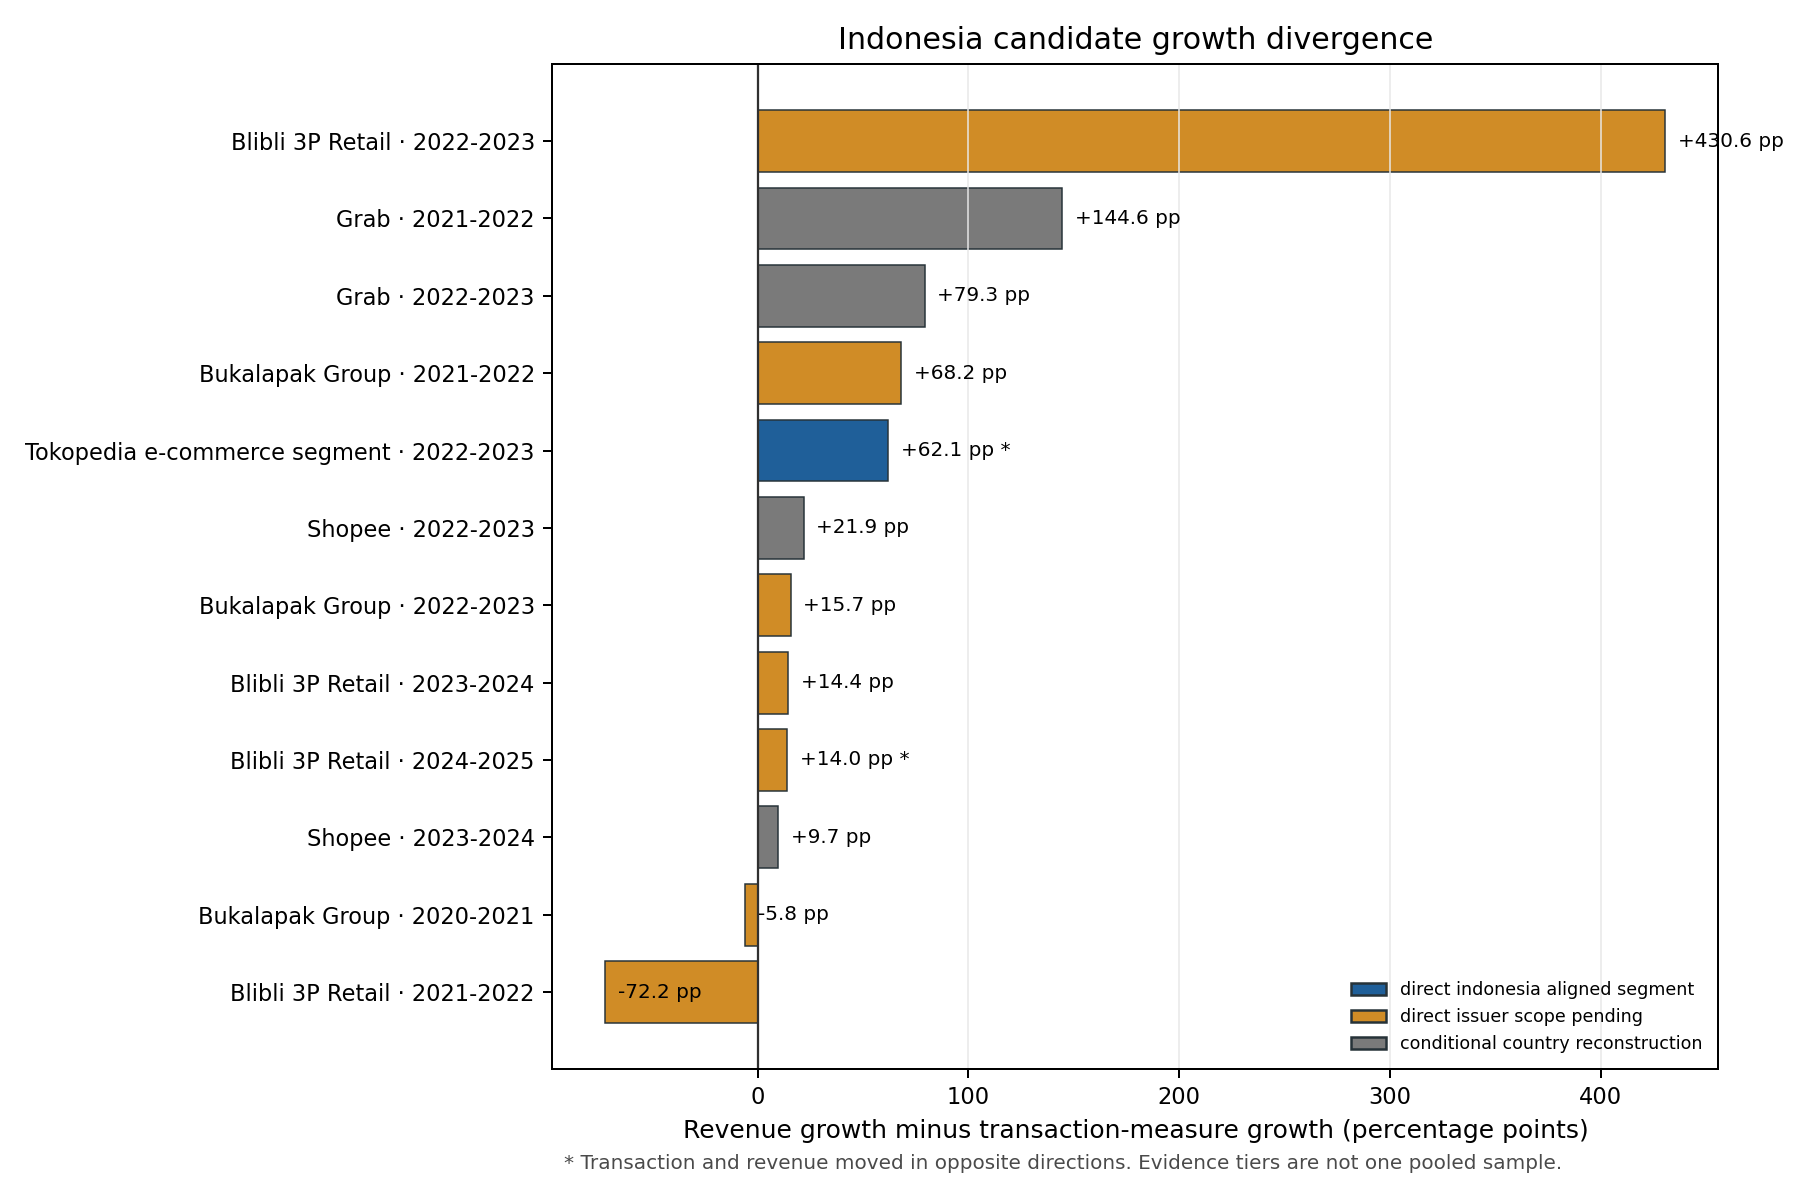

,transition,total_transaction_value_growth_pct,estimated_businesses_growth_pct,implied_value_per_business_growth_pct,marketplace_component_growth_pct,nonmarketplace_component_growth_pct
0,2022-2023,40.60,27.40,10.36,NaN,NaN
1,2023-2024,17.08,15.31,1.54,1.42,20.58


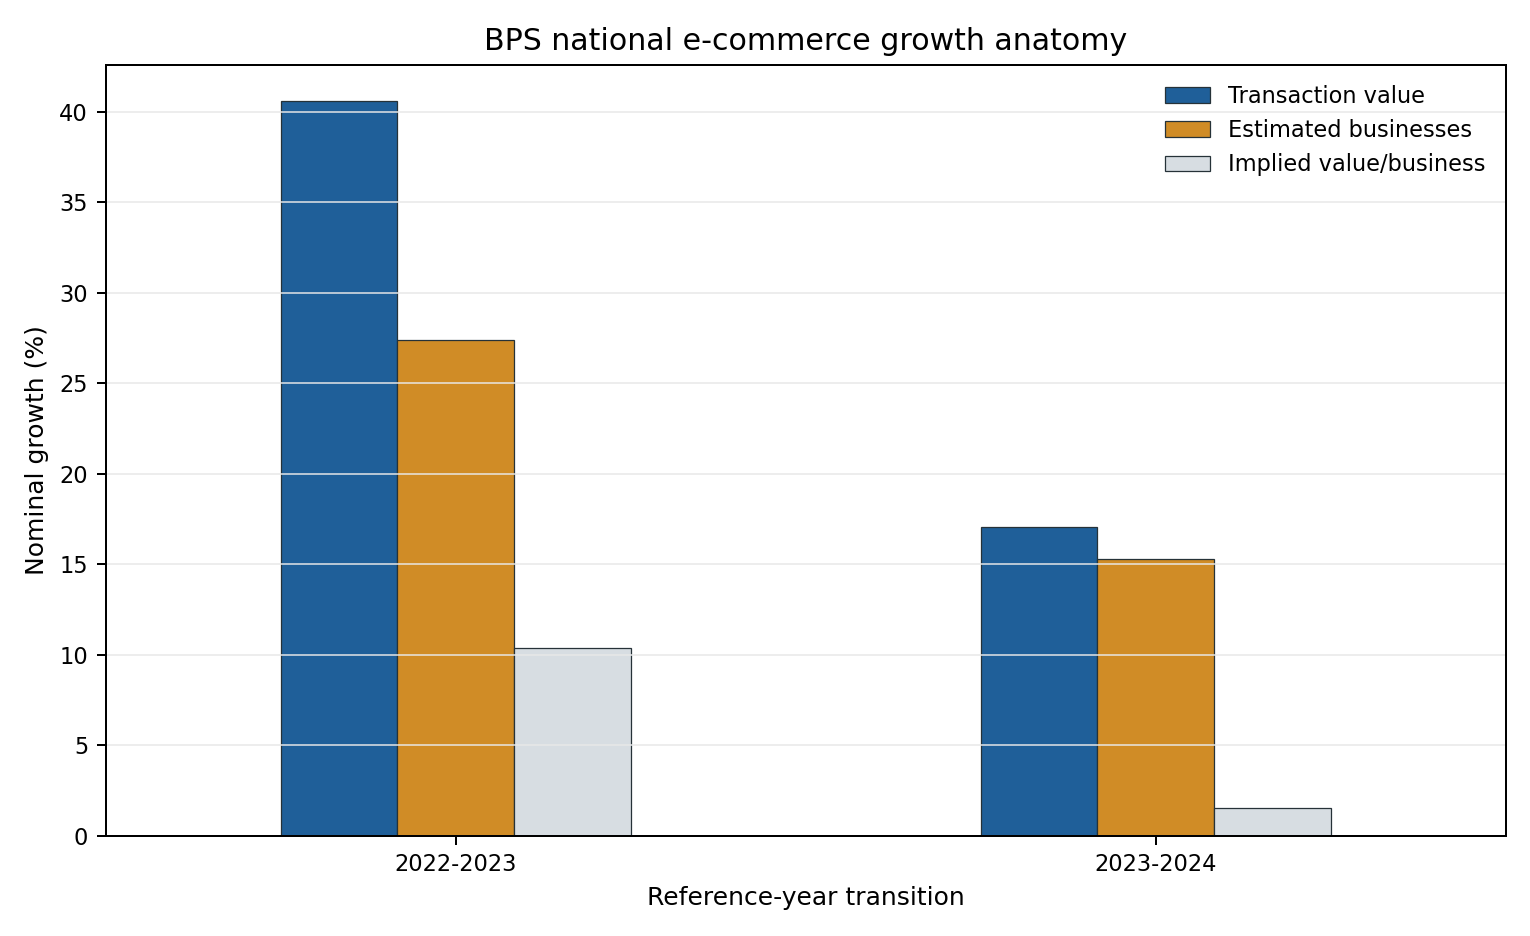

,specification,year_or_change,province_n,pearson_r,pearson_p,spearman_rho,spearman_p,business_count_weighted_r,interpretation
0,province_cross_section,2023,36,0.263,0.121,0.343,0.041,0.490,Ecological cross-section; not a business-level...
1,province_cross_section,2024,38,0.022,0.897,0.113,0.499,0.314,Ecological cross-section; not a business-level...
2,within_province_change,2023-2024,36,0.309,0.066,0.151,0.379,0.099,Ecological first difference; still not a busin...


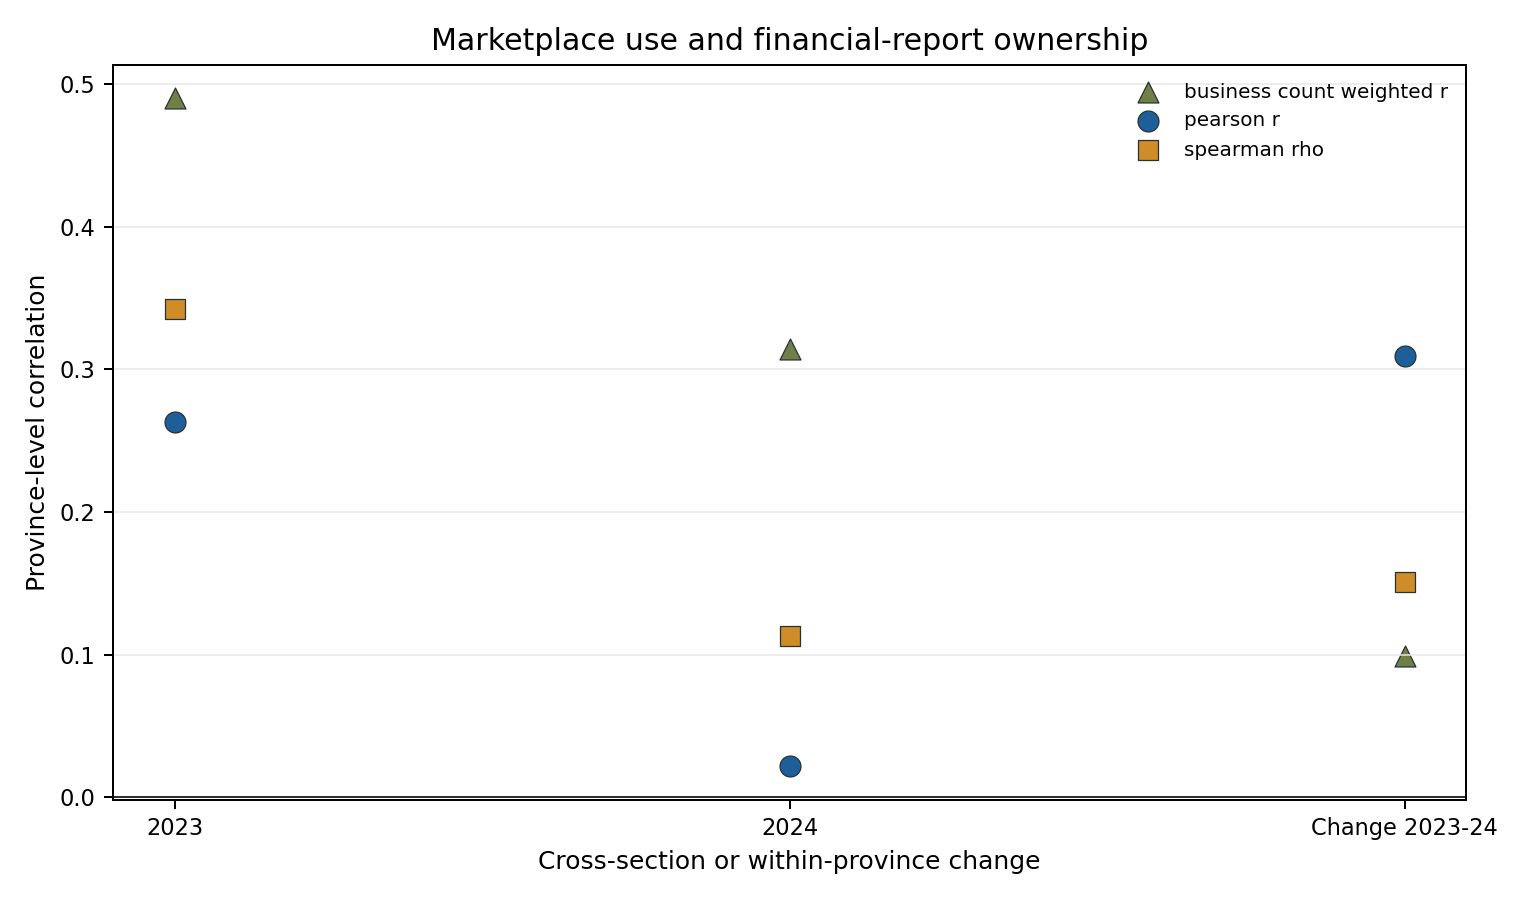

In [2]:
display(transition_summary.round(2))
display(transitions.loc[transitions['opposite_sign'], ['series', 'transition', 'transaction_growth_pct', 'revenue_growth_pct', 'evidence_tier']].round(2))
display(Image(filename=str(root / 'reports/figures/indonesia_candidate_activity_revenue_growth.png')))
display(bps_growth.round(2))
display(Image(filename=str(root / 'reports/figures/bps_national_growth_anatomy.png')))
display(province_results.round(3))
display(Image(filename=str(root / 'reports/figures/bps_marketplace_recordkeeping_stability.png')))

## Takeaways

- Transaction and revenue growth can diverge substantially, including within the direct Tokopedia comparison, but final Indonesia sample admission remains unresolved.
- BPS national aggregates support an extensive-margin interpretation for 2022-2024, not a causal firm-entry or productivity claim.
- The marketplace/recordkeeping hypothesis is not established by province data. Business-level microdata or an official joint cross-tabulation is required.
- Institutional linkage remains a hypothesis rather than an executed empirical result.

In [3]:
display(hypothesis_status)

,hypothesis,status,evidence,boundary
0,H1 transaction and revenue growth can diverge,supported_in_candidate_inventory_not_final_sample,12 within-series transitions; 2 opposite-sign;...,Evidence tiers include scope-pending and condi...
1,H2 aggregate growth partly reflects more busin...,supported_for_2022_2024_aggregate_decomposition,"2023-2024 transaction value +17.08%, businesse...",Nominal arithmetic decomposition; not causal e...
2,H3 marketplace participation predicts financia...,not_established_by_province_evidence,2023-2024 within-province change Pearson r=0.3...,Business-level microdata or an official joint ...
3,H4 institutional linkage failure,not_yet_tested,The repository documents distinct ledgers but ...,Requires implementation and identifier/linkage...
4,H5 measurement choices can alter conclusions,supported_by_existing_measurement_modules,"Reporting vintages, revenue definitions, and b...",Economic consequence must be assessed comparis...
